In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone, BaseEstimator
import importlib
import utils
importlib.reload(utils)
from utils import plot_y_yhat, clean_train_data, error_metric, predict_average, baseline_cross_validation, baseline_cv_predict, select_knn_model, select_polynomial_model
from sklearn.experimental import enable_iterative_imputer  
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer, MissingIndicator
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor, RandomForestRegressor
from catboost import CatBoostRegressor, Pool
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
import lightgbm as lgb
from sklearn.manifold import Isomap

In [135]:
train=pd.read_csv('../data/train_data.csv')
test=pd.read_csv('../data/test_data.csv')
sample_submission=pd.read_csv('../data/sample_submission.csv')

In [136]:
train.head()

,id,Age,Gender,Stage,GeneticRisk,TreatmentType,ComorbidityIndex,TreatmentResponse,SurvivalTime,Censored
0,0,65.0,0,2,1.0,0,0.0,0.0,4.2,0
1,1,68.0,1,2,0.0,1,1.0,1.0,4.7,1
2,2,68.0,1,3,1.0,1,0.0,1.0,3.5,1
3,3,81.0,1,4,1.0,1,3.0,0.0,2.3,0
4,4,59.0,1,2,1.0,0,NaN,0.0,NaN,0


In [137]:
train.isna().sum()

id                     0
Age                    0
Gender                 0
Stage                  0
GeneticRisk           85
TreatmentType          0
ComorbidityIndex      45
TreatmentResponse     29
SurvivalTime         160
Censored               0
dtype: int64

In [138]:
# Keep only rows where SurvivalTime is not NaN
df = train.dropna(subset=["SurvivalTime"])

# Define the columns to impute
cols_to_impute = ["GeneticRisk", "ComorbidityIndex", "TreatmentResponse"]

print("Shape after removing rows with missing SurvivalTime:", df.shape)
print("Remaining NaNs per column:\n", df.isna().sum())

Shape after removing rows with missing SurvivalTime: (240, 10)
Remaining NaNs per column:
 id                    0
Age                   0
Gender                0
Stage                 0
GeneticRisk          47
TreatmentType         0
ComorbidityIndex     30
TreatmentResponse    16
SurvivalTime          0
Censored              0
dtype: int64


### Task 3.1


In [139]:
# Indicator columns for missing values
indicator_cols = [f"{col}_missing" for col in cols_to_impute]

In [140]:
# --- Zero Imputation ---
imputer = SimpleImputer(strategy="constant", fill_value=0, add_indicator=True)
transformed = imputer.fit_transform(df[cols_to_impute])

df_zero = df.copy()
df_zero[cols_to_impute + indicator_cols] = transformed

print("Zero Imputation - Remaining NaNs:\n", df_zero.isna().sum())
df_zero.head(10)

Zero Imputation - Remaining NaNs:
 id                           0
Age                          0
Gender                       0
Stage                        0
GeneticRisk                  0
TreatmentType                0
ComorbidityIndex             0
TreatmentResponse            0
SurvivalTime                 0
Censored                     0
GeneticRisk_missing          0
ComorbidityIndex_missing     0
TreatmentResponse_missing    0
dtype: int64


,id,Age,Gender,Stage,GeneticRisk,TreatmentType,ComorbidityIndex,TreatmentResponse,SurvivalTime,Censored,GeneticRisk_missing,ComorbidityIndex_missing,TreatmentResponse_missing
0,0,65.0,0,2,1.0,0,0.0,0.0,4.2,0,0.0,0.0,0.0
1,1,68.0,1,2,0.0,1,1.0,1.0,4.7,1,0.0,0.0,0.0
2,2,68.0,1,3,1.0,1,0.0,1.0,3.5,1,0.0,0.0,0.0
3,3,81.0,1,4,1.0,1,3.0,0.0,2.3,0,0.0,0.0,0.0
5,5,47.0,1,4,1.0,1,0.0,0.0,2.6,0,0.0,1.0,0.0
9,9,68.0,1,1,0.0,0,1.0,1.0,6.4,0,0.0,0.0,0.0
11,11,56.0,0,2,1.0,0,0.0,1.0,4.1,0,0.0,1.0,0.0
12,12,66.0,1,2,0.0,0,1.0,1.0,9.1,0,0.0,0.0,0.0
14,14,77.0,0,3,0.0,1,2.0,0.0,3.3,1,1.0,0.0,0.0
16,16,63.0,1,1,1.0,1,1.0,1.0,3.0,0,0.0,0.0,0.0


In [141]:
# --- Mean Imputation ---
imputer = SimpleImputer(strategy="mean", add_indicator=True)
transformed = imputer.fit_transform(df[cols_to_impute])

df_mean = df.copy()
df_mean[cols_to_impute + indicator_cols] = transformed

print("Mean Imputation - Remaining NaNs:\n", df_mean.isna().sum())
df_mean.head(10)

Mean Imputation - Remaining NaNs:
 id                           0
Age                          0
Gender                       0
Stage                        0
GeneticRisk                  0
TreatmentType                0
ComorbidityIndex             0
TreatmentResponse            0
SurvivalTime                 0
Censored                     0
GeneticRisk_missing          0
ComorbidityIndex_missing     0
TreatmentResponse_missing    0
dtype: int64


,id,Age,Gender,Stage,GeneticRisk,TreatmentType,ComorbidityIndex,TreatmentResponse,SurvivalTime,Censored,GeneticRisk_missing,ComorbidityIndex_missing,TreatmentResponse_missing
0,0,65.0,0,2,1.000000,0,0.000000,0.0,4.2,0,0.0,0.0,0.0
1,1,68.0,1,2,0.000000,1,1.000000,1.0,4.7,1,0.0,0.0,0.0
2,2,68.0,1,3,1.000000,1,0.000000,1.0,3.5,1,0.0,0.0,0.0
3,3,81.0,1,4,1.000000,1,3.000000,0.0,2.3,0,0.0,0.0,0.0
5,5,47.0,1,4,1.000000,1,1.047619,0.0,2.6,0,0.0,1.0,0.0
9,9,68.0,1,1,0.000000,0,1.000000,1.0,6.4,0,0.0,0.0,0.0
11,11,56.0,0,2,1.000000,0,1.047619,1.0,4.1,0,0.0,1.0,0.0
12,12,66.0,1,2,0.000000,0,1.000000,1.0,9.1,0,0.0,0.0,0.0
14,14,77.0,0,3,0.284974,1,2.000000,0.0,3.3,1,1.0,0.0,0.0
16,16,63.0,1,1,1.000000,1,1.000000,1.0,3.0,0,0.0,0.0,0.0


In [142]:
# --- Median Imputation ---
imputer = SimpleImputer(strategy="median", add_indicator=True)
transformed = imputer.fit_transform(df[cols_to_impute])

df_median = df.copy()
df_median[cols_to_impute + indicator_cols] = transformed

print("Median Imputation - Remaining NaNs:\n", df_median.isna().sum())
df_median.head(10)

Median Imputation - Remaining NaNs:
 id                           0
Age                          0
Gender                       0
Stage                        0
GeneticRisk                  0
TreatmentType                0
ComorbidityIndex             0
TreatmentResponse            0
SurvivalTime                 0
Censored                     0
GeneticRisk_missing          0
ComorbidityIndex_missing     0
TreatmentResponse_missing    0
dtype: int64


,id,Age,Gender,Stage,GeneticRisk,TreatmentType,ComorbidityIndex,TreatmentResponse,SurvivalTime,Censored,GeneticRisk_missing,ComorbidityIndex_missing,TreatmentResponse_missing
0,0,65.0,0,2,1.0,0,0.0,0.0,4.2,0,0.0,0.0,0.0
1,1,68.0,1,2,0.0,1,1.0,1.0,4.7,1,0.0,0.0,0.0
2,2,68.0,1,3,1.0,1,0.0,1.0,3.5,1,0.0,0.0,0.0
3,3,81.0,1,4,1.0,1,3.0,0.0,2.3,0,0.0,0.0,0.0
5,5,47.0,1,4,1.0,1,1.0,0.0,2.6,0,0.0,1.0,0.0
9,9,68.0,1,1,0.0,0,1.0,1.0,6.4,0,0.0,0.0,0.0
11,11,56.0,0,2,1.0,0,1.0,1.0,4.1,0,0.0,1.0,0.0
12,12,66.0,1,2,0.0,0,1.0,1.0,9.1,0,0.0,0.0,0.0
14,14,77.0,0,3,0.0,1,2.0,0.0,3.3,1,1.0,0.0,0.0
16,16,63.0,1,1,1.0,1,1.0,1.0,3.0,0,0.0,0.0,0.0


In [143]:
# --- KNN Imputation + Missing Indicators ---
imputer = KNNImputer(n_neighbors=5, weights="uniform")
indicator = MissingIndicator()  

imputer.fit(df[cols_to_impute])
missing_mask = indicator.fit_transform(df[cols_to_impute]).astype(int)  

transformed = imputer.transform(df[cols_to_impute])

df_knn_indicator = df.copy()
df_knn_indicator[cols_to_impute] = transformed

indicator_cols = [f"{df[cols_to_impute].columns[i]}_missing" for i in indicator.features_]
df_knn_indicator[indicator_cols] = missing_mask

print("KNN Imputation + Indicators - Remaining NaNs:\n", df_knn_indicator.isna().sum())
df_knn_indicator.head(10)

KNN Imputation + Indicators - Remaining NaNs:
 id                           0
Age                          0
Gender                       0
Stage                        0
GeneticRisk                  0
TreatmentType                0
ComorbidityIndex             0
TreatmentResponse            0
SurvivalTime                 0
Censored                     0
GeneticRisk_missing          0
ComorbidityIndex_missing     0
TreatmentResponse_missing    0
dtype: int64


,id,Age,Gender,Stage,GeneticRisk,TreatmentType,ComorbidityIndex,TreatmentResponse,SurvivalTime,Censored,GeneticRisk_missing,ComorbidityIndex_missing,TreatmentResponse_missing
0,0,65.0,0,2,1.0,0,0.0,0.0,4.2,0,0,0,0
1,1,68.0,1,2,0.0,1,1.0,1.0,4.7,1,0,0,0
2,2,68.0,1,3,1.0,1,0.0,1.0,3.5,1,0,0,0
3,3,81.0,1,4,1.0,1,3.0,0.0,2.3,0,0,0,0
5,5,47.0,1,4,1.0,1,1.2,0.0,2.6,0,0,1,0
9,9,68.0,1,1,0.0,0,1.0,1.0,6.4,0,0,0,0
11,11,56.0,0,2,1.0,0,0.4,1.0,4.1,0,0,1,0
12,12,66.0,1,2,0.0,0,1.0,1.0,9.1,0,0,0,0
14,14,77.0,0,3,0.6,1,2.0,0.0,3.3,1,1,0,0
16,16,63.0,1,1,1.0,1,1.0,1.0,3.0,0,0,0,0


In [144]:
# --- KNN Imputation (Distance-weighted) + Missing Indicators ---
imputer = KNNImputer(n_neighbors=5, weights="distance")   
indicator = MissingIndicator()   

imputer.fit(df[cols_to_impute])
missing_mask = indicator.fit_transform(df[cols_to_impute]).astype(int)  
 
transformed = imputer.transform(df[cols_to_impute])
 
df_knn_distance = df.copy()
df_knn_distance[cols_to_impute] = transformed
 
indicator_cols = [f"{df[cols_to_impute].columns[i]}_missing" for i in indicator.features_]
df_knn_distance[indicator_cols] = missing_mask

print("KNN Imputation (Distance) + Indicators - Remaining NaNs:\n", df_knn_distance.isna().sum())
df_knn_distance.head(10)

KNN Imputation (Distance) + Indicators - Remaining NaNs:
 id                           0
Age                          0
Gender                       0
Stage                        0
GeneticRisk                  0
TreatmentType                0
ComorbidityIndex             0
TreatmentResponse            0
SurvivalTime                 0
Censored                     0
GeneticRisk_missing          0
ComorbidityIndex_missing     0
TreatmentResponse_missing    0
dtype: int64


,id,Age,Gender,Stage,GeneticRisk,TreatmentType,ComorbidityIndex,TreatmentResponse,SurvivalTime,Censored,GeneticRisk_missing,ComorbidityIndex_missing,TreatmentResponse_missing
0,0,65.0,0,2,1.0,0,0.0,0.0,4.2,0,0,0,0
1,1,68.0,1,2,0.0,1,1.0,1.0,4.7,1,0,0,0
2,2,68.0,1,3,1.0,1,0.0,1.0,3.5,1,0,0,0
3,3,81.0,1,4,1.0,1,3.0,0.0,2.3,0,0,0,0
5,5,47.0,1,4,1.0,1,1.2,0.0,2.6,0,0,1,0
9,9,68.0,1,1,0.0,0,1.0,1.0,6.4,0,0,0,0
11,11,56.0,0,2,1.0,0,0.4,1.0,4.1,0,0,1,0
12,12,66.0,1,2,0.0,0,1.0,1.0,9.1,0,0,0,0
14,14,77.0,0,3,0.6,1,2.0,0.0,3.3,1,1,0,0
16,16,63.0,1,1,1.0,1,1.0,1.0,3.0,0,0,0,0


In [145]:
# --- Iterative Imputation + Missing Indicators ---
imputer = IterativeImputer(max_iter=10)
indicator = MissingIndicator()   
 
imputer.fit(df[cols_to_impute])
missing_mask = indicator.fit_transform(df[cols_to_impute]).astype(int)   

transformed = imputer.transform(df[cols_to_impute])
 
df_iter_indicator1 = df.copy()
df_iter_indicator1[cols_to_impute] = transformed
 
indicator_cols = [f"{df[cols_to_impute].columns[i]}_missing" for i in indicator.features_]
df_iter_indicator1[indicator_cols] = missing_mask

print("Iterative Imputation + Indicators - Remaining NaNs:\n", df_iter_indicator1.isna().sum())
df_iter_indicator1.head(10)

Iterative Imputation + Indicators - Remaining NaNs:
 id                           0
Age                          0
Gender                       0
Stage                        0
GeneticRisk                  0
TreatmentType                0
ComorbidityIndex             0
TreatmentResponse            0
SurvivalTime                 0
Censored                     0
GeneticRisk_missing          0
ComorbidityIndex_missing     0
TreatmentResponse_missing    0
dtype: int64


,id,Age,Gender,Stage,GeneticRisk,TreatmentType,ComorbidityIndex,TreatmentResponse,SurvivalTime,Censored,GeneticRisk_missing,ComorbidityIndex_missing,TreatmentResponse_missing
0,0,65.0,0,2,1.000000,0,0.000000,0.0,4.2,0,0,0,0
1,1,68.0,1,2,0.000000,1,1.000000,1.0,4.7,1,0,0,0
2,2,68.0,1,3,1.000000,1,0.000000,1.0,3.5,1,0,0,0
3,3,81.0,1,4,1.000000,1,3.000000,0.0,2.3,0,0,0,0
5,5,47.0,1,4,1.000000,1,1.047547,0.0,2.6,0,0,1,0
9,9,68.0,1,1,0.000000,0,1.000000,1.0,6.4,0,0,0,0
11,11,56.0,0,2,1.000000,0,1.047244,1.0,4.1,0,0,1,0
12,12,66.0,1,2,0.000000,0,1.000000,1.0,9.1,0,0,0,0
14,14,77.0,0,3,0.284862,1,2.000000,0.0,3.3,1,1,0,0
16,16,63.0,1,1,1.000000,1,1.000000,1.0,3.0,0,0,0,0


In [146]:
# --- Most Frequent Imputation ---

imputer = SimpleImputer(strategy="most_frequent", add_indicator=True)
transformed = imputer.fit_transform(df[cols_to_impute])

indicator_cols = [f"{col}_missing" for col in cols_to_impute]

df_mostfreq = df.copy()
df_mostfreq[cols_to_impute + indicator_cols] = transformed

print("Most Frequent Imputation - Remaining NaNs:\n", df_mostfreq.isna().sum())
df_mostfreq.head(10)

Most Frequent Imputation - Remaining NaNs:
 id                           0
Age                          0
Gender                       0
Stage                        0
GeneticRisk                  0
TreatmentType                0
ComorbidityIndex             0
TreatmentResponse            0
SurvivalTime                 0
Censored                     0
GeneticRisk_missing          0
ComorbidityIndex_missing     0
TreatmentResponse_missing    0
dtype: int64


,id,Age,Gender,Stage,GeneticRisk,TreatmentType,ComorbidityIndex,TreatmentResponse,SurvivalTime,Censored,GeneticRisk_missing,ComorbidityIndex_missing,TreatmentResponse_missing
0,0,65.0,0,2,1.0,0,0.0,0.0,4.2,0,0.0,0.0,0.0
1,1,68.0,1,2,0.0,1,1.0,1.0,4.7,1,0.0,0.0,0.0
2,2,68.0,1,3,1.0,1,0.0,1.0,3.5,1,0.0,0.0,0.0
3,3,81.0,1,4,1.0,1,3.0,0.0,2.3,0,0.0,0.0,0.0
5,5,47.0,1,4,1.0,1,1.0,0.0,2.6,0,0.0,1.0,0.0
9,9,68.0,1,1,0.0,0,1.0,1.0,6.4,0,0.0,0.0,0.0
11,11,56.0,0,2,1.0,0,1.0,1.0,4.1,0,0.0,1.0,0.0
12,12,66.0,1,2,0.0,0,1.0,1.0,9.1,0,0.0,0.0,0.0
14,14,77.0,0,3,0.0,1,2.0,0.0,3.3,1,1.0,0.0,0.0
16,16,63.0,1,1,1.0,1,1.0,1.0,3.0,0,0.0,0.0,0.0


In [147]:
# --- Iterative Imputation with Missing Indicators ---
imputer = IterativeImputer(max_iter=10, random_state=42, sample_posterior=True)
indicator = MissingIndicator()  

imputer.fit(df[cols_to_impute])
missing_mask = indicator.fit_transform(df[cols_to_impute]).astype(int)  

transformed = imputer.transform(df[cols_to_impute])
 
df_iter_indicator2 = df.copy()
df_iter_indicator2[cols_to_impute] = transformed
 
indicator_cols = [df[cols_to_impute].columns[i] + "_missing" for i in indicator.features_]
df_iter_indicator2[indicator_cols] = missing_mask

print("Iterative Imputation + Indicators - Remaining NaNs:\n", df_iter_indicator2.isna().sum())
df_iter_indicator2.head(10)

Iterative Imputation + Indicators - Remaining NaNs:
 id                           0
Age                          0
Gender                       0
Stage                        0
GeneticRisk                  0
TreatmentType                0
ComorbidityIndex             0
TreatmentResponse            0
SurvivalTime                 0
Censored                     0
GeneticRisk_missing          0
ComorbidityIndex_missing     0
TreatmentResponse_missing    0
dtype: int64


,id,Age,Gender,Stage,GeneticRisk,TreatmentType,ComorbidityIndex,TreatmentResponse,SurvivalTime,Censored,GeneticRisk_missing,ComorbidityIndex_missing,TreatmentResponse_missing
0,0,65.0,0,2,1.000000,0,0.000000,0.0,4.2,0,0,0,0
1,1,68.0,1,2,0.000000,1,1.000000,1.0,4.7,1,0,0,0
2,2,68.0,1,3,1.000000,1,0.000000,1.0,3.5,1,0,0,0
3,3,81.0,1,4,1.000000,1,3.000000,0.0,2.3,0,0,0,0
5,5,47.0,1,4,1.000000,1,1.343652,0.0,2.6,0,0,1,0
9,9,68.0,1,1,0.000000,0,1.000000,1.0,6.4,0,0,0,0
11,11,56.0,0,2,1.000000,0,1.394057,1.0,4.1,0,0,1,0
12,12,66.0,1,2,0.000000,0,1.000000,1.0,9.1,0,0,0,0
14,14,77.0,0,3,-0.633536,1,2.000000,0.0,3.3,1,1,0,0
16,16,63.0,1,1,1.000000,1,1.000000,1.0,3.0,0,0,0,0


In [148]:
N_REPEATS = 10

all_results = {
    "Zero Imputation with": [],
    "Zero Imputation without": [],
    "Mean Imputation with": [],
    "Mean Imputation without": [],
    "Median Imputation with": [],
    "Median Imputation without": [],
    "KNN Imputation (Uniform) with": [],
    "KNN Imputation (Uniform) without": [],
    "KNN Imputation (Distance) with": [],
    "KNN Imputation (Distance) without": [],
    "Iterative Imputation v1 with": [],
    "Iterative Imputation v1 without": [],
    "Most Frequent Imputation with": [],
    "Most Frequent Imputation without": [],
    "Iterative Imputation v2 with": [],
    "Iterative Imputation v2 without": []
}

all_models = {key: [] for key in all_results.keys()}

for i in range(N_REPEATS):
    
    # --- Zero Imputation ---
    models, _, mse_zero_with, _ = baseline_cv_predict(df_zero, keep_missing=True)
    all_results["Zero Imputation with"].append(mse_zero_with)
    all_models["Zero Imputation with"].append(models)
    
    models, _, mse_zero_without, _ = baseline_cv_predict(df_zero, keep_missing=False)
    all_results["Zero Imputation without"].append(mse_zero_without)
    all_models["Zero Imputation without"].append(models)
    
    # --- Mean Imputation ---
    models, _, mse_mean_with, _ = baseline_cv_predict(df_mean, keep_missing=True)
    all_results["Mean Imputation with"].append(mse_mean_with)
    all_models["Mean Imputation with"].append(models)
    
    models, _, mse_mean_without, _ = baseline_cv_predict(df_mean, keep_missing=False)
    all_results["Mean Imputation without"].append(mse_mean_without)
    all_models["Mean Imputation without"].append(models)
    
    # --- Median Imputation ---
    models, _, mse_median_with, _ = baseline_cv_predict(df_median, keep_missing=True)
    all_results["Median Imputation with"].append(mse_median_with)
    all_models["Median Imputation with"].append(models)
    
    models, _, mse_median_without, _ = baseline_cv_predict(df_median, keep_missing=False)
    all_results["Median Imputation without"].append(mse_median_without)
    all_models["Median Imputation without"].append(models)
    
    # --- KNN Imputation (Uniform) ---
    models, _, mse_knn_uniform_with, _ = baseline_cv_predict(df_knn_indicator, keep_missing=True)
    all_results["KNN Imputation (Uniform) with"].append(mse_knn_uniform_with)
    all_models["KNN Imputation (Uniform) with"].append(models)
    
    models, _, mse_knn_uniform_without, _ = baseline_cv_predict(df_knn_indicator, keep_missing=False)
    all_results["KNN Imputation (Uniform) without"].append(mse_knn_uniform_without)
    all_models["KNN Imputation (Uniform) without"].append(models)
    
    # --- KNN Imputation (Distance) ---
    models, _, mse_knn_distance_with, _ = baseline_cv_predict(df_knn_distance, keep_missing=True)
    all_results["KNN Imputation (Distance) with"].append(mse_knn_distance_with)
    all_models["KNN Imputation (Distance) with"].append(models)
    
    models, _, mse_knn_distance_without, _ = baseline_cv_predict(df_knn_distance, keep_missing=False)
    all_results["KNN Imputation (Distance) without"].append(mse_knn_distance_without)
    all_models["KNN Imputation (Distance) without"].append(models)
    
    # --- Iterative Imputation (v1) ---
    models, _, mse_iter1_with, _ = baseline_cv_predict(df_iter_indicator1, keep_missing=True)
    all_results["Iterative Imputation v1 with"].append(mse_iter1_with)
    all_models["Iterative Imputation v1 with"].append(models)
    
    models, _, mse_iter1_without, _ = baseline_cv_predict(df_iter_indicator1, keep_missing=False)
    all_results["Iterative Imputation v1 without"].append(mse_iter1_without)
    all_models["Iterative Imputation v1 without"].append(models)
    
    # --- Most Frequent Imputation ---
    models, _, mse_mostfreq_with, _ = baseline_cv_predict(df_mostfreq, keep_missing=True)
    all_results["Most Frequent Imputation with"].append(mse_mostfreq_with)
    all_models["Most Frequent Imputation with"].append(models)
    
    models, _, mse_mostfreq_without, _ = baseline_cv_predict(df_mostfreq, keep_missing=False)
    all_results["Most Frequent Imputation without"].append(mse_mostfreq_without)
    all_models["Most Frequent Imputation without"].append(models)
    
    # --- Iterative Imputation (v2) ---
    models, _, mse_iter2_with, _ = baseline_cv_predict(df_iter_indicator2, keep_missing=True)
    all_results["Iterative Imputation v2 with"].append(mse_iter2_with)
    all_models["Iterative Imputation v2 with"].append(models)
    
    models, _, mse_iter2_without, _ = baseline_cv_predict(df_iter_indicator2, keep_missing=False)
    all_results["Iterative Imputation v2 without"].append(mse_iter2_without)
    all_models["Iterative Imputation v2 without"].append(models)

mse_results = {}
std_results = {}

for method, scores in all_results.items():
    mse_results[method] = np.mean(scores)
    std_results[method] = np.std(scores)

best_method = min(mse_results, key=mse_results.get)
best_mse_mean = mse_results[best_method]
best_mse_std = std_results[best_method]

best_run_idx = np.argmin(all_results[best_method])
best_models = all_models[best_method][best_run_idx]

mse_sorted = dict(sorted(mse_results.items(), key=lambda item: item[1]))

mse_df = pd.DataFrame({
    "Imputation Method": list(mse_sorted.keys()),
    "Mean MSE": [round(mse_results[k], 3) for k in mse_sorted.keys()],
    "Std MSE": [round(std_results[k], 3) for k in mse_sorted.keys()]
})

mse_df.reset_index(drop=True, inplace=True)

print("\n" + "="*60)
print(f"Results averaged over {N_REPEATS} runs:")
print("="*60)
display(mse_df)

print("\n" + "="*60)
print("BEST METHOD (based on mean MSE):")
print("="*60)
print(f"Method: {best_method}")
print(f"Mean MSE (over {N_REPEATS} runs): {best_mse_mean:.3f} ± {best_mse_std:.3f}")
print(f"Number of models in ensemble: {len(best_models)}")


Results averaged over 10 runs:


,Imputation Method,Mean MSE,Std MSE
0,KNN Imputation (Distance) without,2.523,0.057
1,KNN Imputation (Uniform) without,2.529,0.027
2,KNN Imputation (Uniform) with,2.562,0.048
3,Iterative Imputation v1 without,2.584,0.063
4,Zero Imputation with,2.584,0.043
5,Mean Imputation without,2.593,0.055
6,KNN Imputation (Distance) with,2.612,0.055
7,Median Imputation with,2.620,0.051
8,Iterative Imputation v1 with,2.624,0.034
9,Most Frequent Imputation with,2.632,0.059



BEST METHOD (based on mean MSE):
Method: KNN Imputation (Distance) without
Mean MSE (over 10 runs): 2.523 ± 0.057
Number of models in ensemble: 5


Zero Imputation MSE - with indicators: 2.6527926187692894


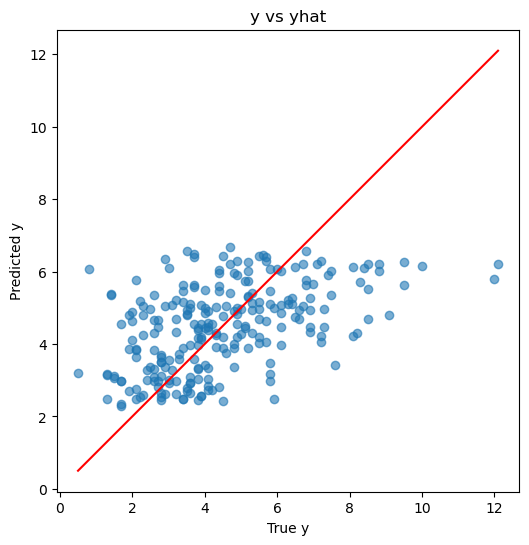

Zero Imputation MSE - without indicators: 2.7088755342963244


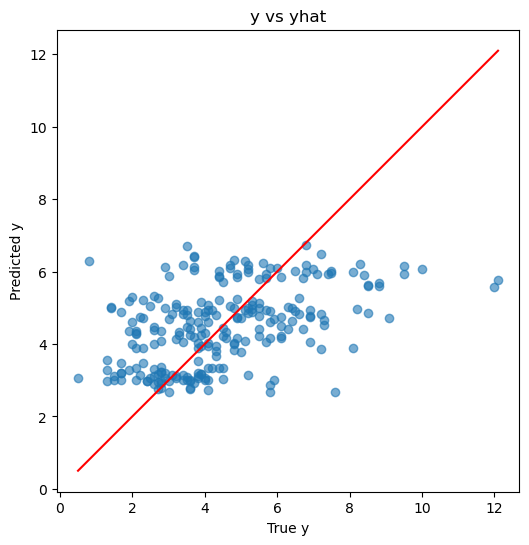

In [149]:
# --- Zero Imputation ---
_, y_pred_zero_with, mse_zero_with, _ = baseline_cv_predict(df_zero, keep_missing=True)
print("Zero Imputation MSE - with indicators:", mse_zero_with)
plot_y_yhat(df_zero["SurvivalTime"], y_pred_zero_with)

_, y_pred_zero_without, mse_zero_without, _ =  baseline_cv_predict(df_zero, keep_missing=False)
print("Zero Imputation MSE - without indicators:", mse_zero_without)
plot_y_yhat(df_zero["SurvivalTime"], y_pred_zero_without)

Mean Imputation MSE - with indicators: 2.6568849009349873


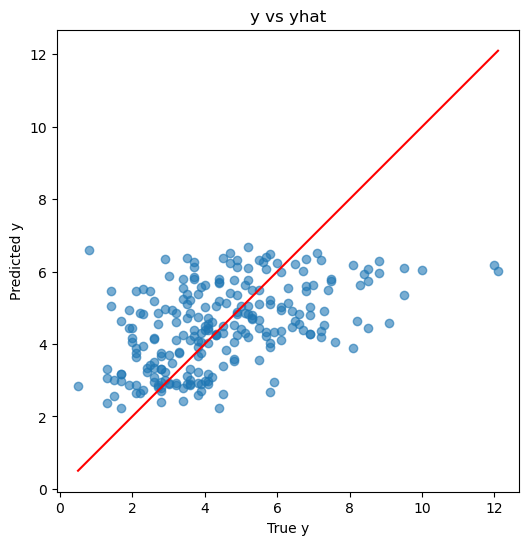

Mean Imputation MSE - without indicators: 2.642557970204089


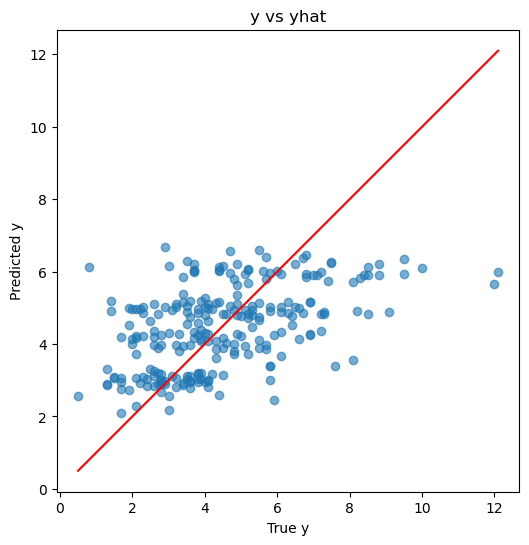

In [150]:
# --- Mean Imputation ---
_, y_pred_mean_with, mse_mean_with, _ = baseline_cv_predict(df_mean, keep_missing=True)
print("Mean Imputation MSE - with indicators:", mse_mean_with)
plot_y_yhat(df_mean["SurvivalTime"], y_pred_mean_with)

_, y_pred_mean_without, mse_mean_without, _ = baseline_cv_predict(df_mean, keep_missing=False)
print("Mean Imputation MSE - without indicators:", mse_mean_without)
plot_y_yhat(df_mean["SurvivalTime"], y_pred_mean_without)

Median Imputation MSE - with indicators: 2.659137560789146


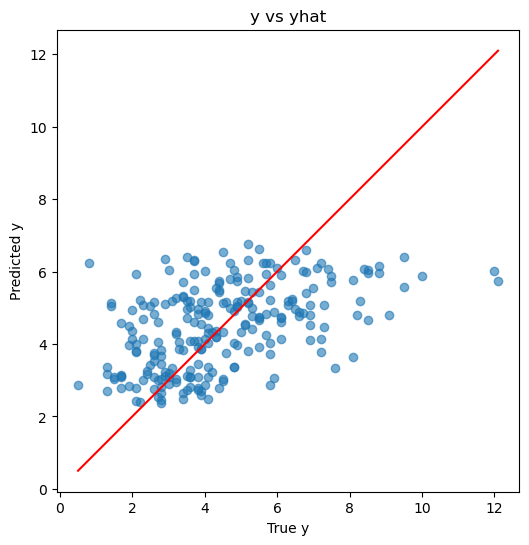

Median Imputation MSE - without indicators: 2.6297887857721585


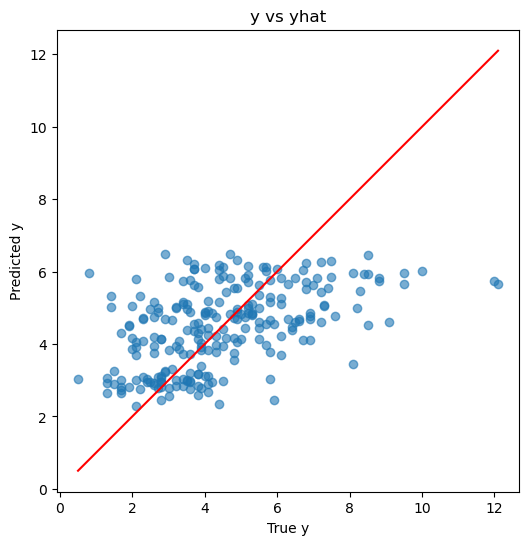

In [151]:
# --- Median Imputation ---
_, y_pred_median_with, mse_median_with, _ = baseline_cv_predict(df_median, keep_missing=True)
print("Median Imputation MSE - with indicators:", mse_median_with)
plot_y_yhat(df_median["SurvivalTime"], y_pred_median_with)

_, y_pred_median_without, mse_median_without, _ = baseline_cv_predict(df_median, keep_missing=False)
print("Median Imputation MSE - without indicators:", mse_median_without)
plot_y_yhat(df_median["SurvivalTime"], y_pred_median_without)

KNN Imputation MSE - with indicators: 2.5149474655238966


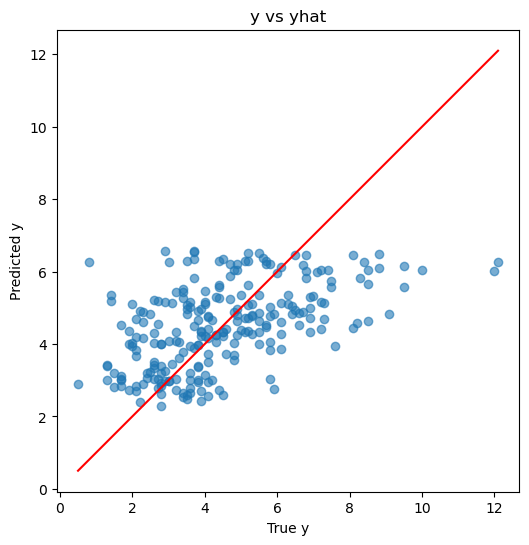

KNN Imputation MSE - without indicators: 2.5090291842676975


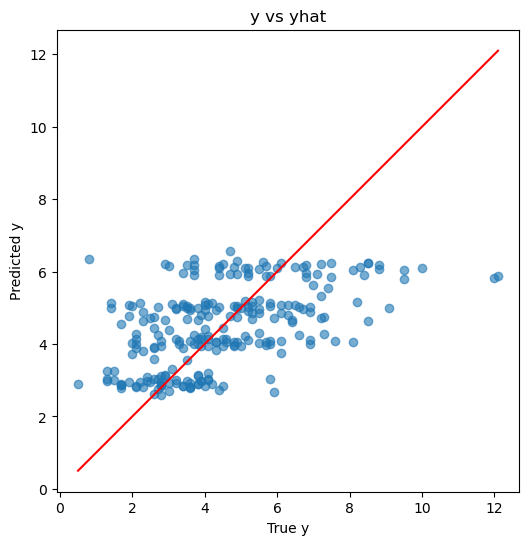

In [160]:
# --- KNN Imputation ---
_, y_pred_knn_with, mse_knn_with, _ = baseline_cv_predict(df_knn_indicator, keep_missing=True)
print("KNN Imputation MSE - with indicators:", mse_knn_with)
plot_y_yhat(df_knn_indicator["SurvivalTime"], y_pred_knn_with)

models, y_pred_knn_without, mse_knn_without, _ = baseline_cv_predict(df_knn_indicator, keep_missing=False)
print("KNN Imputation MSE - without indicators:", mse_knn_without)
plot_y_yhat(df_knn_indicator["SurvivalTime"], y_pred_knn_without)

KNN Distance Imputation MSE - with indicators: 2.546973817020535


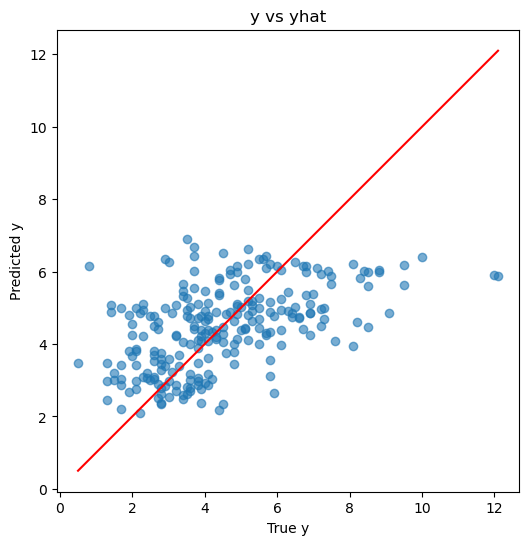

KNN Distance Imputation MSE - without indicators: 2.6295892574397923


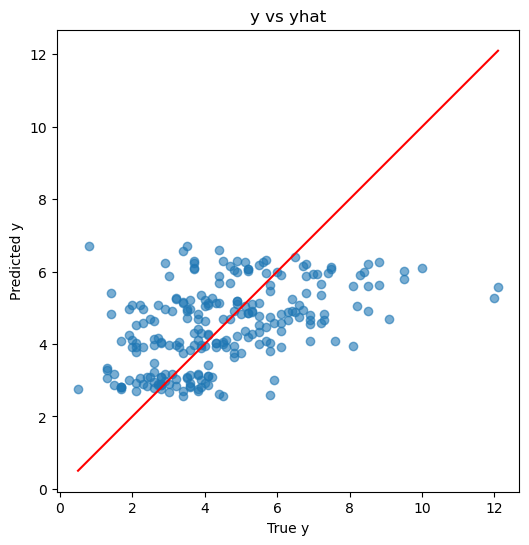

In [153]:
# --- KNN Imputation (Distance) ---
_, y_pred_knn_with, mse_knn_with, _ = baseline_cv_predict(df_knn_distance, keep_missing=True)
print("KNN Distance Imputation MSE - with indicators:", mse_knn_with)
plot_y_yhat(df_knn_distance["SurvivalTime"], y_pred_knn_with)

models, y_pred_knn_without, mse_knn_without, _ = baseline_cv_predict(df_knn_distance, keep_missing=False)
print("KNN Distance Imputation MSE - without indicators:", mse_knn_without)
plot_y_yhat(df_knn_distance["SurvivalTime"], y_pred_knn_without)

Iterative Imputation v1 MSE - with indicators: 2.625052716390776


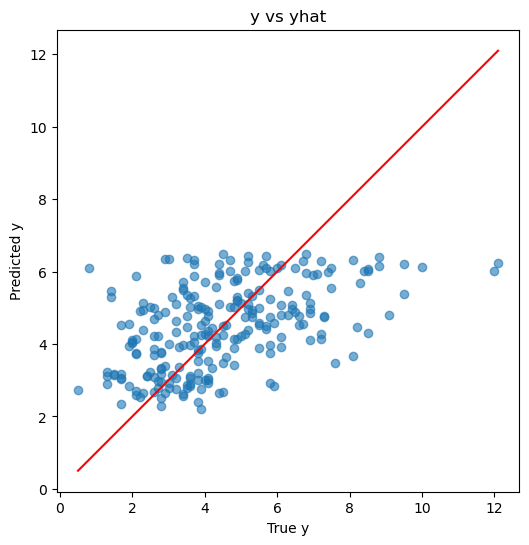

Iterative Imputation v1 MSE - without indicators: 2.546424517531894


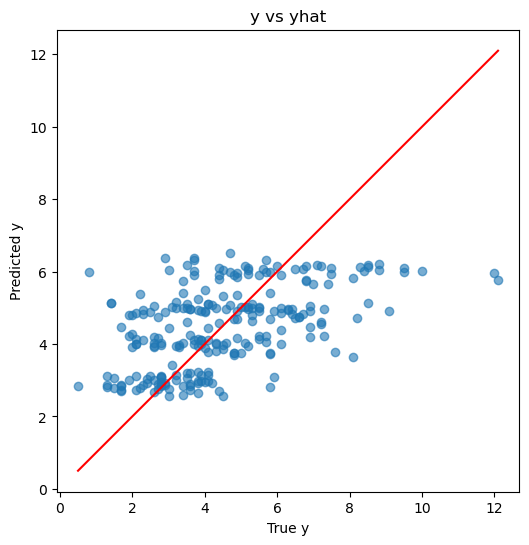

In [154]:
# --- Iterative Imputation + Indicators (v1) ---
_, y_pred_iter1_with, mse_iter1_with, _ = baseline_cv_predict(df_iter_indicator1, keep_missing=True)
print("Iterative Imputation v1 MSE - with indicators:", mse_iter1_with)
plot_y_yhat(df_iter_indicator1["SurvivalTime"], y_pred_iter1_with)

_, y_pred_iter1_without, mse_iter1_without, _ = baseline_cv_predict(df_iter_indicator1, keep_missing=False)
print("Iterative Imputation v1 MSE - without indicators:", mse_iter1_without)
plot_y_yhat(df_iter_indicator1["SurvivalTime"], y_pred_iter1_without)

Most Frequent Imputation MSE - with indicators: 2.6231802783051807


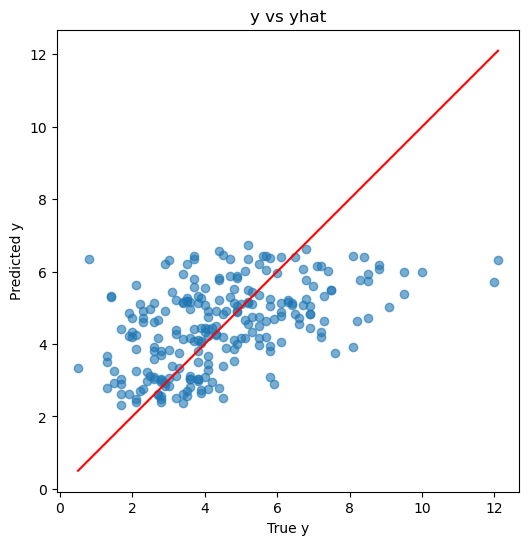

Most Frequent Imputation MSE - without indicators: 2.568677919519828


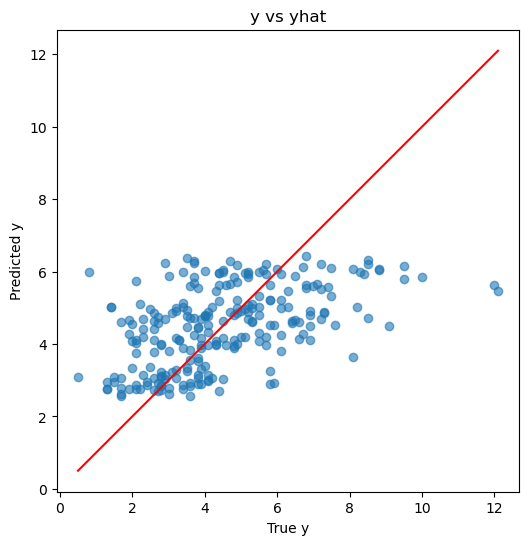

In [155]:
# --- Most Frequent Imputation ---
_, y_pred_mostfreq_with, mse_mostfreq_with, _ = baseline_cv_predict(df_mostfreq, keep_missing=True)
print("Most Frequent Imputation MSE - with indicators:", mse_mostfreq_with)
plot_y_yhat(df_mostfreq["SurvivalTime"], y_pred_mostfreq_with)

_, y_pred_mostfreq_without, mse_mostfreq_without, _ = baseline_cv_predict(df_mostfreq, keep_missing=False)
print("Most Frequent Imputation MSE - without indicators:", mse_mostfreq_without)
plot_y_yhat(df_mostfreq["SurvivalTime"], y_pred_mostfreq_without)

Iterative Imputation v2 MSE - with indicators: 2.8008730267732243


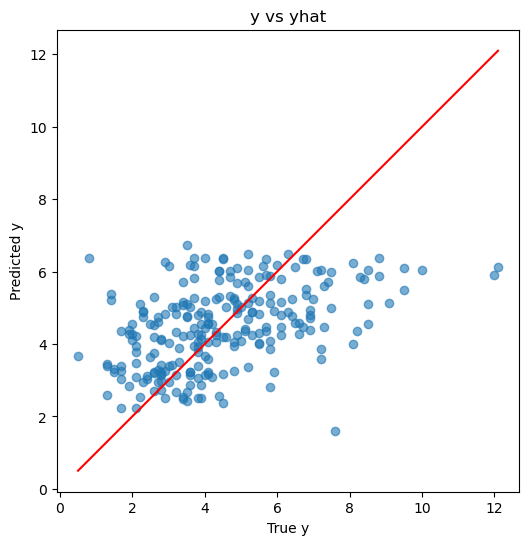

Iterative Imputation v2 MSE - without indicators: 2.722302228719327


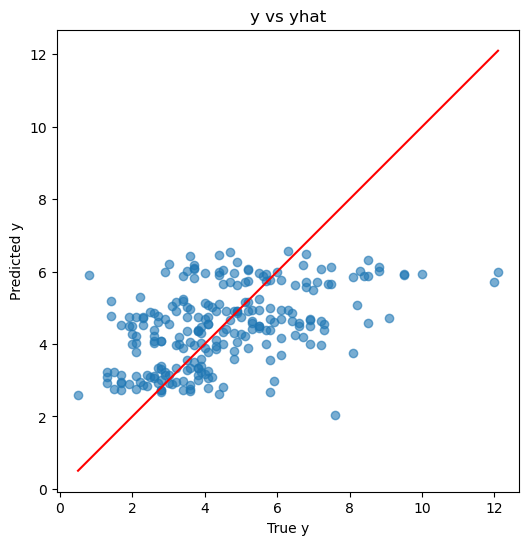

In [156]:
# --- Iterative Imputation + Indicators (v2) ---
_, y_pred_iter2_with, mse_iter2_with, _ = baseline_cv_predict(df_iter_indicator2, keep_missing=True)
print("Iterative Imputation v2 MSE - with indicators:", mse_iter2_with)
plot_y_yhat(df_iter_indicator2["SurvivalTime"], y_pred_iter2_with)

_, y_pred_iter2_without, mse_iter2_without, _ = baseline_cv_predict(df_iter_indicator2, keep_missing=False)
print("Iterative Imputation v2 MSE - without indicators:", mse_iter2_without)
plot_y_yhat(df_iter_indicator2["SurvivalTime"], y_pred_iter2_without)


#### TASK 3.2

RESULTS OVER CROSS-VALIDATION
HGB             | Mean: 3.359623 | Std: 0.884348
CatBoost        | Mean: 3.512528 | Std: 1.011108
CatBoost_AFT    | Mean: 2.925302 | Std: 0.994220
XGBoost         | Mean: 3.856528 | Std: 0.722966
LightGBM        | Mean: 3.099196 | Std: 0.865438

Best model: CatBoost_AFT
   Mean Error: 2.925302

PREDICTION PLOTS (y vs yhat - average of 5 folds)

HGB (Error: 3.359623)


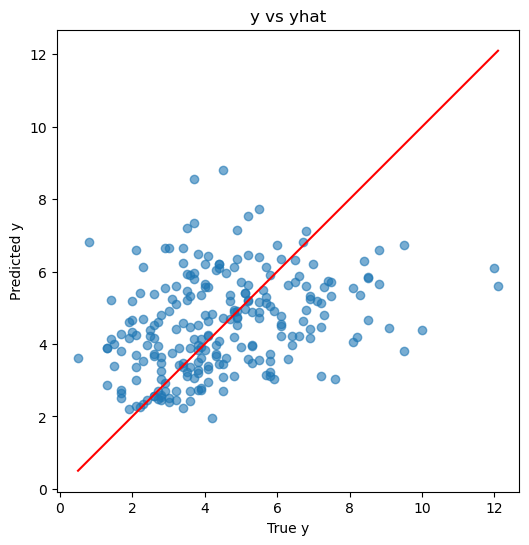


CatBoost (Error: 3.512528)


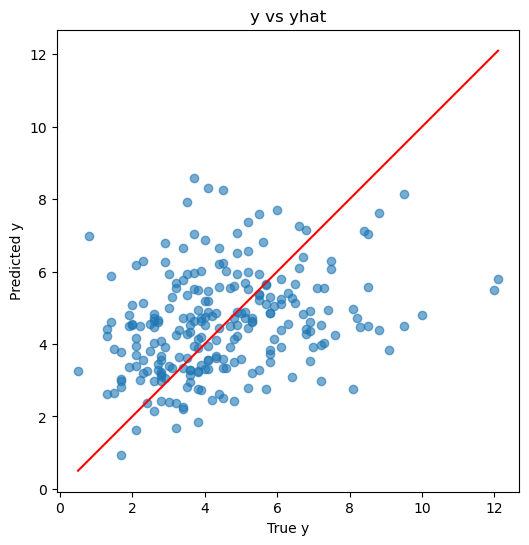


CatBoost_AFT (Error: 2.925302)


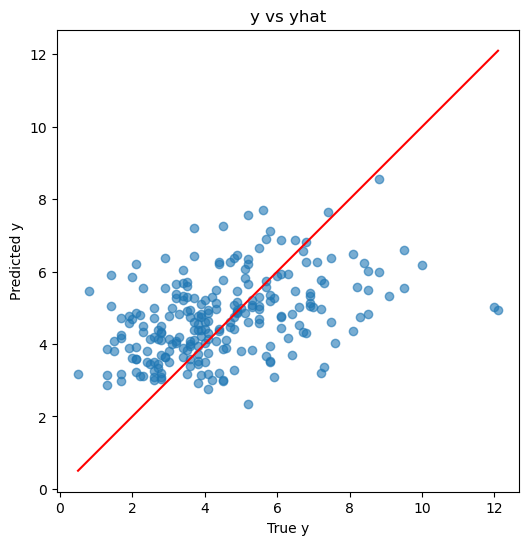


XGBoost (Error: 3.856528)


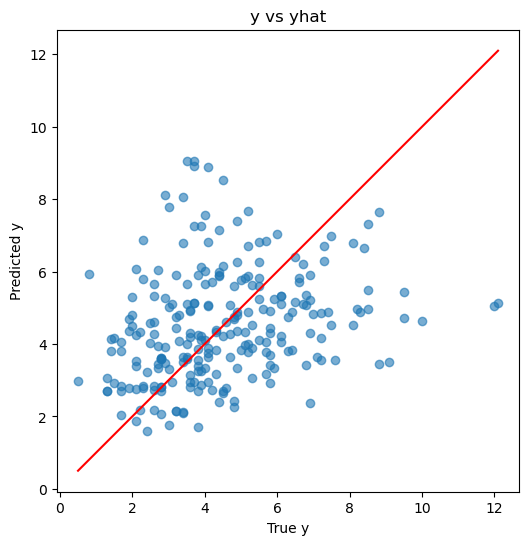


LightGBM (Error: 3.099196)


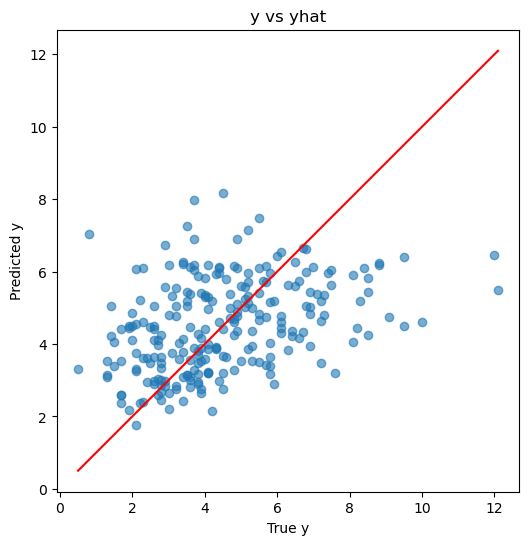

In [114]:
#WITHOUT IMPUTATION
X = train.drop(columns=["id", "SurvivalTime", "Censored"])
y = train["SurvivalTime"]
censored = train["Censored"]
mask = ~y.isna()
X_valid = X[mask].reset_index(drop=True)
y_valid = y[mask].reset_index(drop=True)
c_valid = censored[mask].reset_index(drop=True)

y_lower = y_valid.values.copy()
y_upper = y_valid.values.copy()
censored_mask = (c_valid == 1).values
y_upper[censored_mask] = np.inf  

kf = KFold(n_splits=5, shuffle=True)
models_dict = {
    "HGB": {"models": [], "errors": [], "predictions": []},
    "CatBoost": {"models": [], "errors": [], "predictions": []},
    "CatBoost_AFT": {"models": [], "errors": [], "predictions": []},
    "XGBoost": {"models": [], "errors": [], "predictions": []},
    "LightGBM": {"models": [], "errors": [], "predictions": []}
}

y_true_all = []
indices_all = []

for train_idx, val_idx in kf.split(X_valid):
    X_train, X_val = X_valid.iloc[train_idx], X_valid.iloc[val_idx]
    y_train, y_val = y_valid.iloc[train_idx], y_valid.iloc[val_idx]
    c_train, c_val = c_valid.iloc[train_idx], c_valid.iloc[val_idx]
    
    y_true_all.append(y_val.values)
    indices_all.append(val_idx)

    # --- HistGradientBoostingRegressor ---
    hgb = HistGradientBoostingRegressor(max_iter=200)
    hgb.fit(X_train, y_train)
    y_pred = hgb.predict(X_val)
    models_dict["HGB"]["models"].append(hgb)
    models_dict["HGB"]["errors"].append(error_metric(y_val.values, y_pred, c_val.values))
    models_dict["HGB"]["predictions"].append(y_pred)

     # --- CatBoostRegressor ---
    cat = CatBoostRegressor(iterations=500, learning_rate=0.1, depth=6, verbose=0)
    cat.fit(X_train, y_train)
    y_pred = cat.predict(X_val)
    models_dict["CatBoost"]["models"].append(cat)
    models_dict["CatBoost"]["errors"].append(error_metric(y_val.values, y_pred, c_val.values))
    models_dict["CatBoost"]["predictions"].append(y_pred)

    # --- CatBoost AFT ---
    y_train_lower = y_lower[train_idx]
    y_train_upper = y_upper[train_idx].copy()
    y_val_lower = y_lower[val_idx]
    y_val_upper = y_upper[val_idx].copy() 
    y_train_upper[y_train_upper == np.inf] = -1
    y_val_upper[y_val_upper == np.inf] = -1
     
    train_pool = Pool(
        data=X_train,
        label=np.column_stack([y_train_lower, y_train_upper])
    )
    
    val_pool = Pool(
        data=X_val,
        label=np.column_stack([y_val_lower, y_val_upper])
    )
    
    cat_aft = CatBoostRegressor(
        loss_function='SurvivalAft:dist=Normal',
        eval_metric='SurvivalAft',
        iterations=500,
        learning_rate=0.1,
        depth=6,
        verbose=0
    )
     
    cat_aft.fit(train_pool, eval_set=val_pool)
    y_pred = cat_aft.predict(val_pool, prediction_type='Exponent')
    models_dict["CatBoost_AFT"]["models"].append(cat_aft)
    models_dict["CatBoost_AFT"]["errors"].append(error_metric(y_val.values, y_pred, c_val.values))
    models_dict["CatBoost_AFT"]["predictions"].append(y_pred)

    # --- XGBoostRegressor ---
    xgb = XGBRegressor(n_estimators=500, learning_rate=0.1)
    xgb.fit(X_train, y_train)
    y_pred = xgb.predict(X_val)
    models_dict["XGBoost"]["models"].append(xgb)
    models_dict["XGBoost"]["errors"].append(error_metric(y_val.values, y_pred, c_val.values))
    models_dict["XGBoost"]["predictions"].append(y_pred)
    
     # --- LightGBMRegressor ---
    lgbm = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, verbose=-1)
    lgbm.fit(X_train, y_train)
    y_pred = lgbm.predict(X_val)
    models_dict["LightGBM"]["models"].append(lgbm)
    models_dict["LightGBM"]["errors"].append(error_metric(y_val.values, y_pred, c_val.values))
    models_dict["LightGBM"]["predictions"].append(y_pred)

print("="*60)
print("RESULTS OVER CROSS-VALIDATION")
print("="*60)
for name, info in models_dict.items():
    mean_err = np.mean(info['errors'])
    std_err = np.std(info['errors'])
    print(f"{name:15s} | Mean: {mean_err:.6f} | Std: {std_err:.6f}")

best_model = min(models_dict.items(), key=lambda x: np.mean(x[1]['errors']))
print(f"\nBest model: {best_model[0]}")
print(f"   Mean Error: {np.mean(best_model[1]['errors']):.6f}")

y_true_concat = np.concatenate(y_true_all)

print("\n" + "="*60)
print("PREDICTION PLOTS (y vs yhat - average of 5 folds)")
print("="*60)

for name, info in models_dict.items():
    y_pred_concat = np.concatenate(info['predictions'])
    mean_err = np.mean(info['errors'])
    print(f"\n{'='*60}")
    print(f"{name} (Error: {mean_err:.6f})")
    print(f"{'='*60}")
    plot_y_yhat(y_true_concat, y_pred_concat)

RESULTS OVER CROSS-VALIDATION
HGB             | Mean: 3.370622 | Std: 0.395581
CatBoost        | Mean: 3.546018 | Std: 1.001264
CatBoost_AFT    | Mean: 3.042541 | Std: 0.798394
DecisionTree    | Mean: 5.096656 | Std: 0.906135
RandomForest    | Mean: 3.266461 | Std: 0.550917
XGBoost         | Mean: 3.783864 | Std: 0.631256
LightGBM        | Mean: 3.177607 | Std: 0.413146

Best model: CatBoost_AFT
   Mean Error: 3.042541

PREDICTION PLOTS (y vs yhat - average of 5 folds)

HGB (Error: 3.370622)


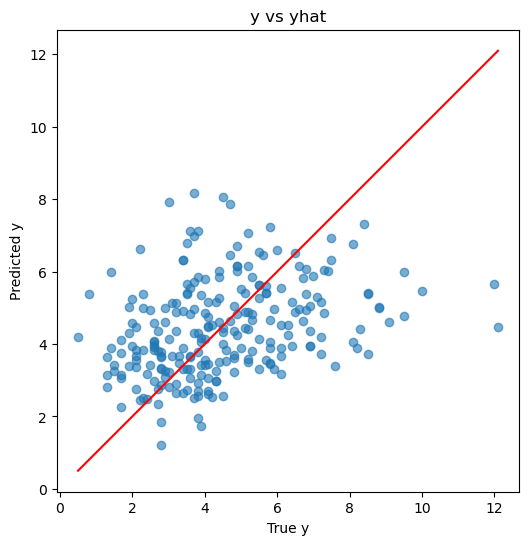


CatBoost (Error: 3.546018)


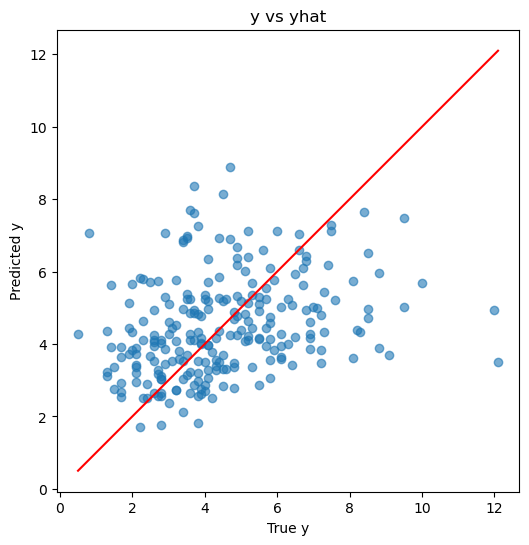


CatBoost_AFT (Error: 3.042541)


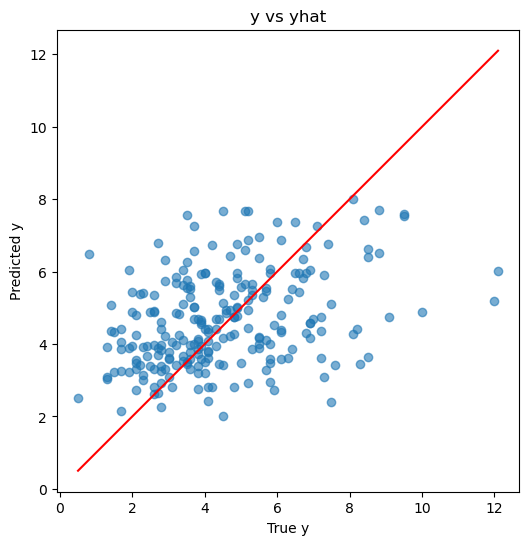


DecisionTree (Error: 5.096656)


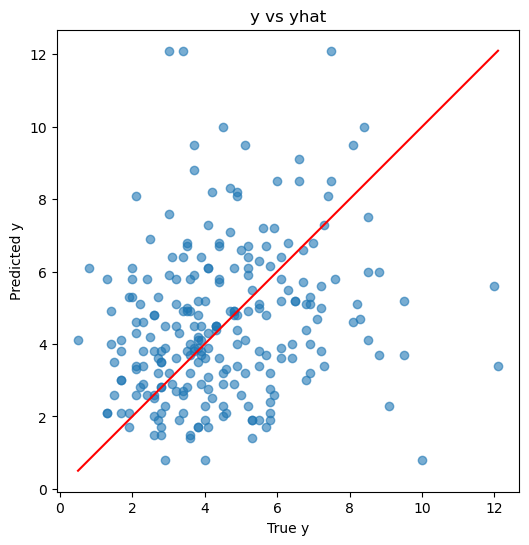


RandomForest (Error: 3.266461)


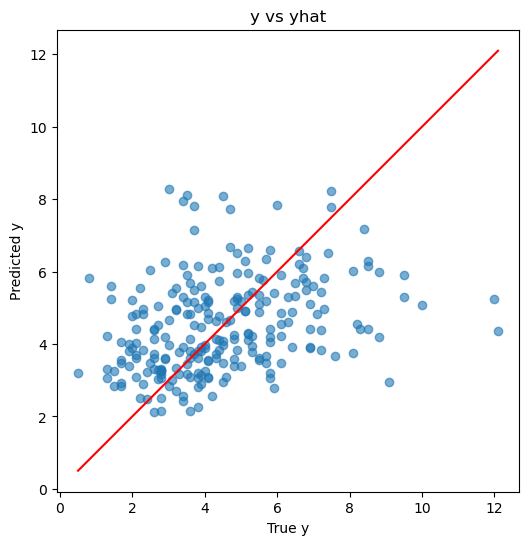


XGBoost (Error: 3.783864)


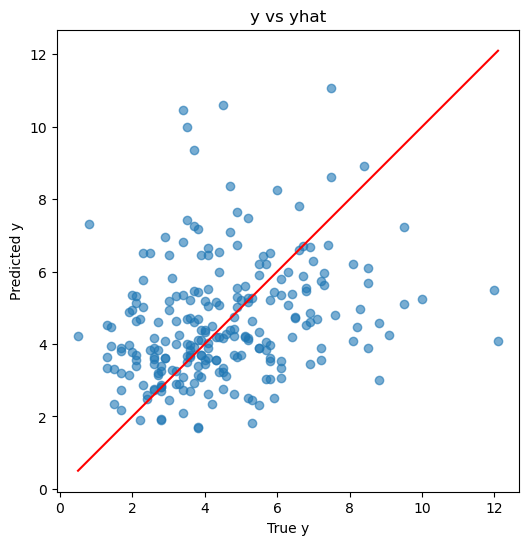


LightGBM (Error: 3.177607)


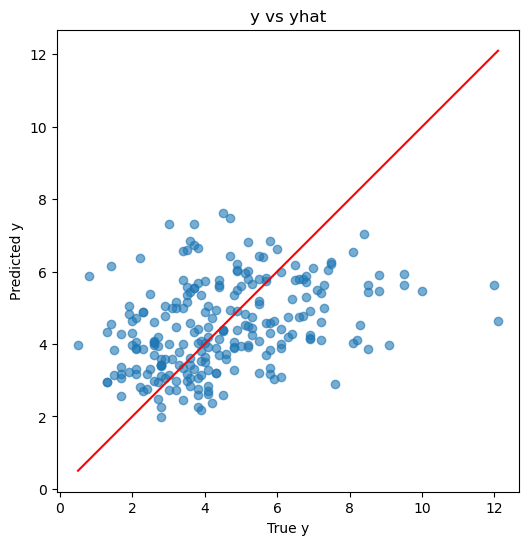

In [165]:
# KNN Imputation 
cols_to_impute = ["GeneticRisk", "ComorbidityIndex", "TreatmentResponse"]
df_iter1 = train.copy()
imputer = KNNImputer(n_neighbors=5, weights="uniform")
df_iter1[cols_to_impute] = imputer.fit_transform(df_iter1[cols_to_impute])

X = df_iter1.drop(columns=["id", "SurvivalTime", "Censored"])
y = df_iter1["SurvivalTime"]
censored = df_iter1["Censored"]

mask = ~y.isna()
X_valid = X[mask]
y_valid = y[mask]
c_valid = censored[mask]

# Preparation for CatBoost AFT
y_lower = y_valid.values.copy()
y_upper = y_valid.values.copy()
censored_mask = (c_valid == 1).values
y_upper[censored_mask] = np.inf  
 
kf = KFold(n_splits=5, shuffle=True)

models_dict = {
    "HGB": {"models": [], "errors": [], "predictions": []},
    "CatBoost": {"models": [], "errors": [], "predictions": []},
    "CatBoost_AFT": {"models": [], "errors": [], "predictions": []},
    "DecisionTree": {"models": [], "errors": [], "predictions": []},
    "RandomForest": {"models": [], "errors": [], "predictions": []},
    "XGBoost": {"models": [], "errors": [], "predictions": []},
    "LightGBM": {"models": [], "errors": [], "predictions": []},
}

y_true_all = []

for train_idx, val_idx in kf.split(X_valid):
    X_train, X_val = X_valid.iloc[train_idx], X_valid.iloc[val_idx]
    y_train, y_val = y_valid.iloc[train_idx], y_valid.iloc[val_idx]
    c_train, c_val = c_valid.iloc[train_idx], c_valid.iloc[val_idx]
    
    y_true_all.append(y_val.values)

    # --- HistGradientBoostingRegressor ---
    hgb = HistGradientBoostingRegressor(max_iter=200)
    hgb.fit(X_train, y_train)
    y_pred = hgb.predict(X_val)
    models_dict["HGB"]["models"].append(hgb)
    models_dict["HGB"]["errors"].append(error_metric(y_val.values, y_pred, c_val.values))
    models_dict["HGB"]["predictions"].append(y_pred)

    # --- CatBoostRegressor ---
    cat = CatBoostRegressor(iterations=500, learning_rate=0.1, depth=6, verbose=0)
    cat.fit(X_train, y_train)
    y_pred = cat.predict(X_val)
    models_dict["CatBoost"]["models"].append(cat)
    models_dict["CatBoost"]["errors"].append(error_metric(y_val.values, y_pred, c_val.values))
    models_dict["CatBoost"]["predictions"].append(y_pred)

    # --- CatBoost AFT ---
    y_train_lower = y_lower[train_idx]
    y_train_upper = y_upper[train_idx].copy()
    y_val_lower = y_lower[val_idx]
    y_val_upper = y_upper[val_idx].copy()

    y_train_upper[y_train_upper == np.inf] = -1
    y_val_upper[y_val_upper == np.inf] = -1
    
    train_pool = Pool(
        data=X_train,
        label=np.column_stack([y_train_lower, y_train_upper])
    )
    val_pool = Pool(
        data=X_val,
        label=np.column_stack([y_val_lower, y_val_upper])
    )

    cat_aft = CatBoostRegressor(
        loss_function='SurvivalAft:dist=Normal',  # Normal / Logistic / Extreme
        eval_metric='SurvivalAft',
        iterations=500,
        learning_rate=0.1,
        depth=6,
        verbose=0
    )
    cat_aft.fit(train_pool, eval_set=val_pool)
    y_pred = cat_aft.predict(val_pool, prediction_type='Exponent')
    models_dict["CatBoost_AFT"]["models"].append(cat_aft)
    models_dict["CatBoost_AFT"]["errors"].append(error_metric(y_val.values, y_pred, c_val.values))
    models_dict["CatBoost_AFT"]["predictions"].append(y_pred)

    # --- DecisionTreeRegressor ---
    dt = DecisionTreeRegressor()
    dt.fit(X_train, y_train)
    y_pred = dt.predict(X_val)
    models_dict["DecisionTree"]["models"].append(dt)
    models_dict["DecisionTree"]["errors"].append(error_metric(y_val.values, y_pred, c_val.values))
    models_dict["DecisionTree"]["predictions"].append(y_pred)

    # --- RandomForestRegressor ---
    rf = RandomForestRegressor(n_estimators=1000)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_val)
    models_dict["RandomForest"]["models"].append(rf)
    models_dict["RandomForest"]["errors"].append(error_metric(y_val.values, y_pred, c_val.values))
    models_dict["RandomForest"]["predictions"].append(y_pred)

    # --- XGBoostRegressor ---
    xgb = XGBRegressor(n_estimators=500, learning_rate=0.1)
    xgb.fit(X_train, y_train)
    y_pred = xgb.predict(X_val)
    models_dict["XGBoost"]["models"].append(xgb)
    models_dict["XGBoost"]["errors"].append(error_metric(y_val.values, y_pred, c_val.values))
    models_dict["XGBoost"]["predictions"].append(y_pred)

    # --- LightGBMRegressor ---
    lgbm = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, verbose=-1)
    lgbm.fit(X_train, y_train)
    y_pred = lgbm.predict(X_val)
    models_dict["LightGBM"]["models"].append(lgbm)
    models_dict["LightGBM"]["errors"].append(error_metric(y_val.values, y_pred, c_val.values))
    models_dict["LightGBM"]["predictions"].append(y_pred)

print("="*60)
print("RESULTS OVER CROSS-VALIDATION")
print("="*60)
for name, info in models_dict.items():
    mean_err = np.mean(info['errors'])
    std_err = np.std(info['errors'])
    print(f"{name:15s} | Mean: {mean_err:.6f} | Std: {std_err:.6f}")

best_model = min(models_dict.items(), key=lambda x: np.mean(x[1]['errors']))
print(f"\nBest model: {best_model[0]}")
print(f"   Mean Error: {np.mean(best_model[1]['errors']):.6f}")

y_true_concat = np.concatenate(y_true_all)

print("\n" + "="*60)
print("PREDICTION PLOTS (y vs yhat - average of 5 folds)")
print("="*60)

for name, info in models_dict.items():
    y_pred_concat = np.concatenate(info['predictions'])
    mean_err = np.mean(info['errors'])
    print(f"\n{'='*60}")
    print(f"{name} (Error: {mean_err:.6f})")
    print(f"{'='*60}")
    plot_y_yhat(y_true_concat, y_pred_concat)

RESULTS OVER CROSS-VALIDATION
HGB             | Mean: 3.344827 | Std: 1.087801
CatBoost        | Mean: 3.496995 | Std: 0.836159
CatBoost_AFT    | Mean: 3.072120 | Std: 1.044328
DecisionTree    | Mean: 4.811365 | Std: 0.937551
RandomForest    | Mean: 3.229183 | Std: 0.881716
XGBoost         | Mean: 3.850281 | Std: 1.397908
LightGBM        | Mean: 3.125707 | Std: 0.983161

Best model: CatBoost_AFT
   Mean Error: 3.072120

PREDICTION PLOTS (y vs yhat - average of 5 folds)

HGB (Error: 3.344827)


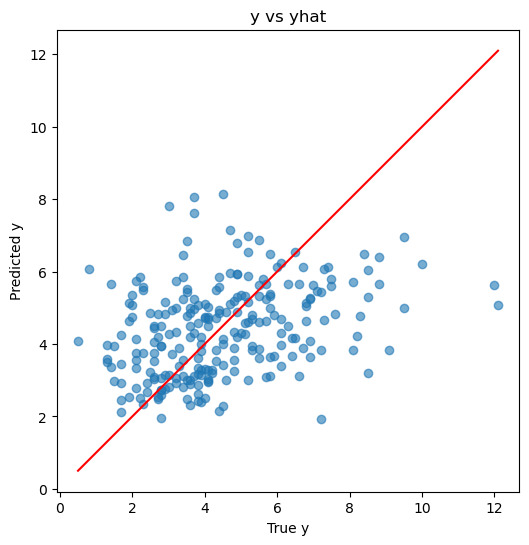


CatBoost (Error: 3.496995)


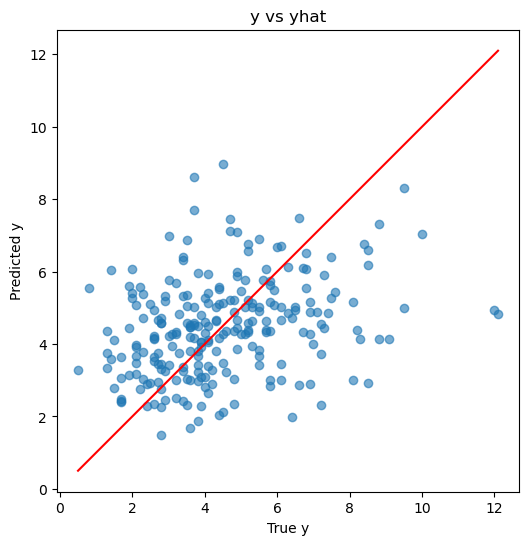


CatBoost_AFT (Error: 3.072120)


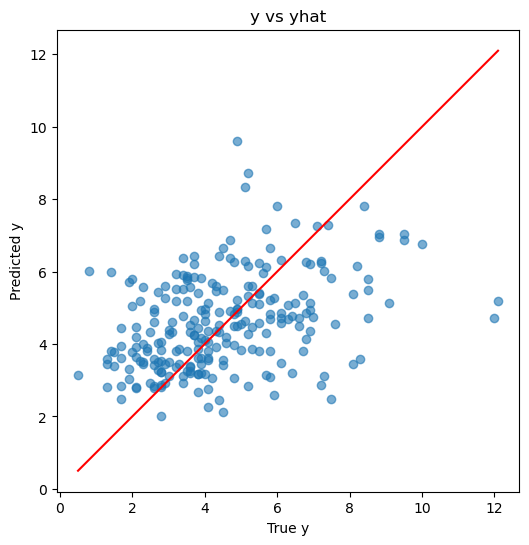


DecisionTree (Error: 4.811365)


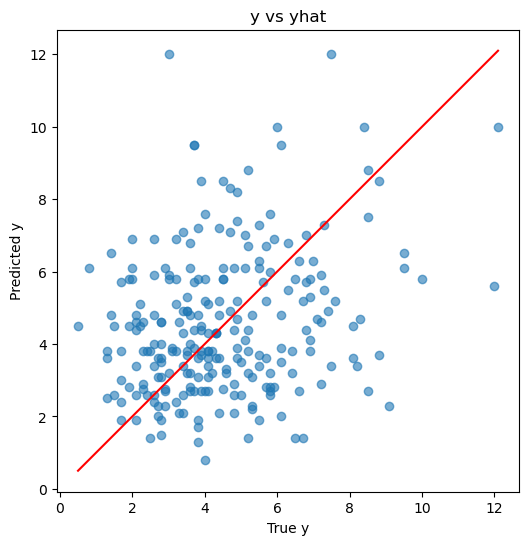


RandomForest (Error: 3.229183)


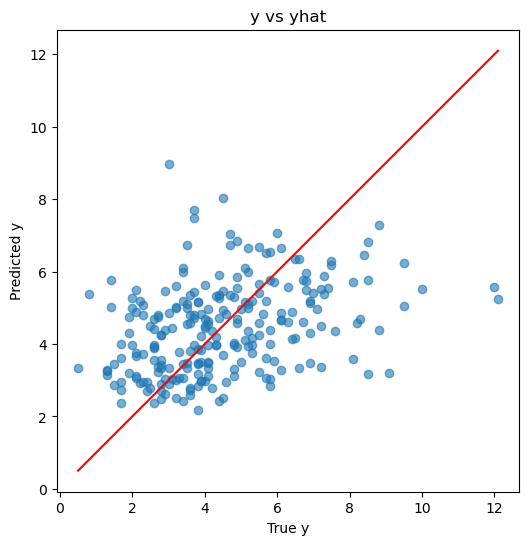


XGBoost (Error: 3.850281)


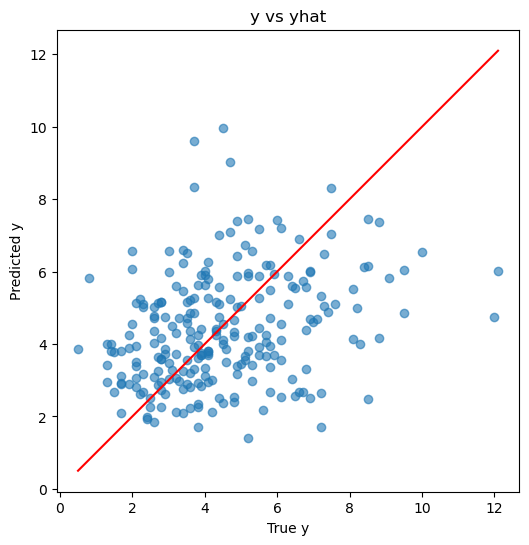


LightGBM (Error: 3.125707)


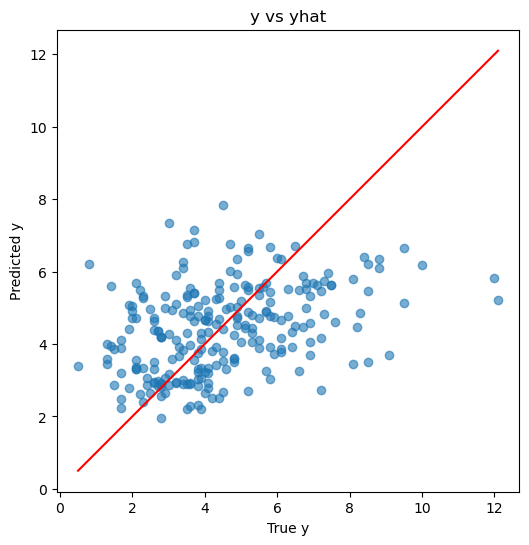

In [116]:
#  Iterative Imputation 
cols_to_impute = ["GeneticRisk", "ComorbidityIndex", "TreatmentResponse"]
df_iter1 = train.copy()
 
imputer = IterativeImputer(max_iter=10)
 
df_iter1[cols_to_impute] = imputer.fit_transform(df_iter1[cols_to_impute])
 
X = df_iter1.drop(columns=["id", "SurvivalTime", "Censored"])
y = df_iter1["SurvivalTime"]
censored = df_iter1["Censored"]

mask = ~y.isna()
X_valid = X[mask]
y_valid = y[mask]
c_valid = censored[mask]
 
y_lower = y_valid.values.copy()
y_upper = y_valid.values.copy()
censored_mask = (c_valid == 1).values
y_upper[censored_mask] = np.inf  
 
kf = KFold(n_splits=5, shuffle=True)

models_dict = {
    "HGB": {"models": [], "errors": [], "predictions": []},
    "CatBoost": {"models": [], "errors": [], "predictions": []},
    "CatBoost_AFT": {"models": [], "errors": [], "predictions": []},
    "DecisionTree": {"models": [], "errors": [], "predictions": []},
    "RandomForest": {"models": [], "errors": [], "predictions": []},
    "XGBoost": {"models": [], "errors": [], "predictions": []},
    "LightGBM": {"models": [], "errors": [], "predictions": []},
}

y_true_all = []

for train_idx, val_idx in kf.split(X_valid):
    X_train, X_val = X_valid.iloc[train_idx], X_valid.iloc[val_idx]
    y_train, y_val = y_valid.iloc[train_idx], y_valid.iloc[val_idx]
    c_train, c_val = c_valid.iloc[train_idx], c_valid.iloc[val_idx]
    
    y_true_all.append(y_val.values)

    # --- HistGradientBoostingRegressor ---
    hgb = HistGradientBoostingRegressor(max_iter=200)
    hgb.fit(X_train, y_train)
    y_pred = hgb.predict(X_val)
    models_dict["HGB"]["models"].append(hgb)
    models_dict["HGB"]["errors"].append(error_metric(y_val.values, y_pred, c_val.values))
    models_dict["HGB"]["predictions"].append(y_pred)

    # --- CatBoostRegressor ---
    cat = CatBoostRegressor(iterations=500, learning_rate=0.1, depth=6, verbose=0)
    cat.fit(X_train, y_train)
    y_pred = cat.predict(X_val)
    models_dict["CatBoost"]["models"].append(cat)
    models_dict["CatBoost"]["errors"].append(error_metric(y_val.values, y_pred, c_val.values))
    models_dict["CatBoost"]["predictions"].append(y_pred)

    # --- CatBoost AFT ---
    y_train_lower = y_lower[train_idx]
    y_train_upper = y_upper[train_idx].copy()
    y_val_lower = y_lower[val_idx]
    y_val_upper = y_upper[val_idx].copy()
 
    y_train_upper[y_train_upper == np.inf] = -1
    y_val_upper[y_val_upper == np.inf] = -1

    train_pool = Pool(
        data=X_train,
        label=np.column_stack([y_train_lower, y_train_upper])
    )
    val_pool = Pool(
        data=X_val,
        label=np.column_stack([y_val_lower, y_val_upper])
    )

    cat_aft = CatBoostRegressor(
        loss_function='SurvivalAft:dist=Normal',  # Normal / Logistic / Extreme
        eval_metric='SurvivalAft',
        iterations=500,
        learning_rate=0.1,
        depth=6,
        verbose=0
    )
    cat_aft.fit(train_pool, eval_set=val_pool)
    y_pred = cat_aft.predict(val_pool, prediction_type='Exponent')
    models_dict["CatBoost_AFT"]["models"].append(cat_aft)
    models_dict["CatBoost_AFT"]["errors"].append(error_metric(y_val.values, y_pred, c_val.values))
    models_dict["CatBoost_AFT"]["predictions"].append(y_pred)

    # --- DecisionTreeRegressor ---
    dt = DecisionTreeRegressor()
    dt.fit(X_train, y_train)
    y_pred = dt.predict(X_val)
    models_dict["DecisionTree"]["models"].append(dt)
    models_dict["DecisionTree"]["errors"].append(error_metric(y_val.values, y_pred, c_val.values))
    models_dict["DecisionTree"]["predictions"].append(y_pred)

    # --- RandomForestRegressor ---
    rf = RandomForestRegressor(n_estimators=1000)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_val)
    models_dict["RandomForest"]["models"].append(rf)
    models_dict["RandomForest"]["errors"].append(error_metric(y_val.values, y_pred, c_val.values))
    models_dict["RandomForest"]["predictions"].append(y_pred)

    # --- XGBoostRegressor ---
    xgb = XGBRegressor(n_estimators=500, learning_rate=0.1)
    xgb.fit(X_train, y_train)
    y_pred = xgb.predict(X_val)
    models_dict["XGBoost"]["models"].append(xgb)
    models_dict["XGBoost"]["errors"].append(error_metric(y_val.values, y_pred, c_val.values))
    models_dict["XGBoost"]["predictions"].append(y_pred)

    # --- LightGBMRegressor ---
    lgbm = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, verbose=-1)
    lgbm.fit(X_train, y_train)
    y_pred = lgbm.predict(X_val)
    models_dict["LightGBM"]["models"].append(lgbm)
    models_dict["LightGBM"]["errors"].append(error_metric(y_val.values, y_pred, c_val.values))
    models_dict["LightGBM"]["predictions"].append(y_pred)

print("="*60)
print("RESULTS OVER CROSS-VALIDATION")
print("="*60)
for name, info in models_dict.items():
    mean_err = np.mean(info['errors'])
    std_err = np.std(info['errors'])
    print(f"{name:15s} | Mean: {mean_err:.6f} | Std: {std_err:.6f}")

best_model = min(models_dict.items(), key=lambda x: np.mean(x[1]['errors']))
print(f"\nBest model: {best_model[0]}")
print(f"   Mean Error: {np.mean(best_model[1]['errors']):.6f}")

y_true_concat = np.concatenate(y_true_all)

print("\n" + "="*60)
print("PREDICTION PLOTS (y vs yhat - average of 5 folds)")
print("="*60)

for name, info in models_dict.items():
    y_pred_concat = np.concatenate(info['predictions'])
    mean_err = np.mean(info['errors'])
    print(f"\n{'='*60}")
    print(f"{name} (Error: {mean_err:.6f})")
    print(f"{'='*60}")
    plot_y_yhat(y_true_concat, y_pred_concat)